<a href="https://colab.research.google.com/github/laxhidualopez06/Py---1--Laxhidua/blob/main/MN_U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
A = np.array([[10,1,-1],
              [2,10,1], # Segunda ecuación
              [2,3,10]]) #Tercera ecuación

b = np.array([11,12,13]) #Vector de términos independientes

x = np.zeros(3) #Vector inicial de aproximación (x0,y0,z0)

tol = 1e-6 #Tolerancia para el criterio del paro

max_iter = 100 #Número máximo de iteraciones permitidos

for k in range(max_iter): #Bucle principal de iteraciones

    x_new = np.zeros(3) # Vector donde se guardará la nueva aproximación

    x_new[0] = (11 - x[1] + x[2]) / 10 # Despeje de x a partir de la primera ecuación

    x_new[1] = (12 - 2*x[0] - x[2]) / 10 # Despeje de x a partir de la segunda ecuación

    x_new[2] = (13 - 2*x[0] - 3*x[1]) / 10 # Despeje de x a partir de la tercera ecuación

    if np.linalg.norm(x_new - x) < tol: #Verifica si el cambio entre iteraciones es menos que
        break # Termina el proceso si se cumple el criterio de convergencia

    x = x_new # Actualiza la aproximación para la siguiente iteración

print("Solución aproximada: ", x_new) # Imprime la solución aproximada
print("Iteraciones: ", k+1) # Imprime el número de iteraciones realizada


Solución aproximada:  [1.07971022 0.91304339 0.71014493]
Iteraciones:  9


In [ ]:
import numpy as np

tol = 1e-6

for k in range(100):

  x_old = x.copy() # Guarda la solución anterior para calcular el error

  x[0] = (11 - x[1] + x[2]) / 10 # Despeje de x a partir de la primera ecuación

  x[1] = (12 - 2*x[0] - x[2]) / 10 # Despeje de x a partir de la segunda ecuación

  x[2] = (13 - 2*x[0] - 3*x[1]) / 10 # Despeje de x a partir de la tercera ecuación


## **Ejercicio 1 - Visualización gráfica del sistema**   --> 12/03/2026

# **Sistema de ecuaciones no lineales**

/tmp/ipykernel_231/4058227811.py:7: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt(4 - x**2)  # Calcula la parte superior del círculo usando la ecuación x^2 + y^2 = 4
/tmp/ipykernel_231/4058227811.py:8: RuntimeWarning: invalid value encountered in sqrt
  y2 = -np.sqrt(4 - x**2)  # Calcula la parte inferior del círculo


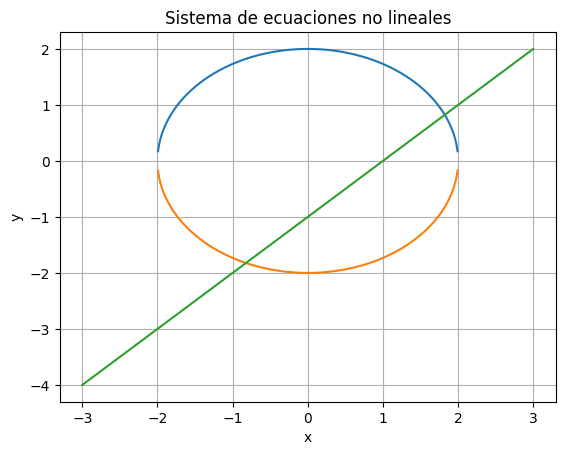

In [ ]:
## Sistema de ecuaciones no lineales
import numpy as np  # Importa la biblioteca NumPy para cálculos numéricos y manejo de arreglos
import matplotlib.pyplot as plt  # Importa Matplotlib para generar gráficos

x = np.linspace(-3, 3, 400)  # Genera 400 valores igualmente espaciados entre -3 y 3

y1 = np.sqrt(4 - x**2)  # Calcula la parte superior del círculo usando la ecuación x^2 + y^2 = 4
y2 = -np.sqrt(4 - x**2)  # Calcula la parte inferior del círculo

y_line = x - 1  # Calcula los valores de y de la recta definida por la ecuación x - y = 1

plt.plot(x, y1)  # Grafica la mitad superior del círculo
plt.plot(x, y2)  # Grafica la mitad inferior del círculo
plt.plot(x, y_line)  # Grafica la recta del sistema

plt.xlabel("x")  # Etiqueta del eje horizontal
plt.ylabel("y")  # Etiqueta del eje vertical
plt.title("Sistema de ecuaciones no lineales")  # Título del gráfico

plt.grid()  # Activa la cuadrícula para facilitar la visualización

plt.show()  # Muestra la figura generada
#que es una expancio de taylor y que es la matriz jacobiana y que compone

# **Ejercicio 2 - Resolución con Scipy --> 17/03/2026**

In [ ]:
import numpy as np # Biblioteca para cálculos numéricos
from scipy.optimize import fsolve # Importa el método fsolve para resolver sistema no lineales

def sistema(vars): #Define la función que representa el sistema de ecuaciones
  x, y = vars # Separa las variables del vector de entrada
  f1 = x**2 + y**2 - 4 # Primera ecuación del sistema
  f2 = x - y - 1 # Segunda ecuación del sistema
  return [f1, f2] # Devuelve el sistema evaluado

sol = fsolve(sistema, [1, 1]) # Busca la solución usando como aproximación inicial (1,1)

print("Solución aproximada:", sol) # Imprime la solución encontrada


Solución aproximada: [1.82287566 0.82287566]


# **Ejercicio 3 - Evaluación del error --> 17/03/2026**

In [ ]:
import numpy as np # Biblioteca para cálculos numéricos

x = 1.822 # Valor aproximado de la variable x obtenido numéricamente
y = 0.822 # Valor aproximado de la variable y obtenido numéricamente

f1 = x**2 + y**2 - 4 # Evalúa la primera ecuación usando la solución aproximada
f2 = x - y - 1 # Evalúa la segunda ecuación usando la solución aproximada

print("Error ecuación 1:", f1) # Muestra el error residual de la primera ecuación
print("Error ecuación 2:", f2) # Muestra el error residual de la segunda ecuación

Error ecuación 1: -0.0046319999999999695
Error ecuación 2: 0.0


## **Ejercicio 1 - Verificación de convergeencia** --> 18/03/2026

In [ ]:
import numpy as np

A = np.array([[10,1,-1],  # Define la primera fila de la matriz de coeficentes del sistema
              [2,10,1],   # Define la segunda fila de la matriz
              [2,3,10]])  # Define la tercera fila de la matriz

D = np.diag(np.diag(A)) # Extrae la matriz diagonal de A

L = -np.tril(A,-1) # Obtiene la parte triangular inferior de la matriz A con signo negativo

U = -np.triu(A,1)  # Obtiene la parte triangular superior de la matriz A con signo negativo

T = np.linalg.inv(D).dot(L+U) # Calcula la matriz de iteración del método de Jacobi

eigenvalues = np.linalg.eigvals(T) # Calcula los eigenvalores de la matriz de iteración

rho = max(abs(eigenvalues)) # Calcula el radio espectral (máximo valor absoluto)

print("Radio espectral:", rho) # Imprime el valor del radio espectral

if rho < 1: # Verifica si el radio espectral es menor que 1
    print("El método converge") # Indica que  el método iterativo converge
else:
  print("El método diverge") # Indica que el método iterativo no converge



Radio espectral: 0.21958233454456474
El método converge


## **Ejercicio 2 - Observación de la convergencia** --> 18/03/2026

In [ ]:
import numpy as np

A = np.array([[10,1,-1],  # Define la primera fila de la matriz de coeficentes del sistema
              [2,10,1],   # Define la segunda fila de la matriz
              [2,3,10]])  # Define la tercera fila de la matriz

b = np.array([11,12,13]) # Vector de términos independientes

x = np.zeros(3) # Vector inicial aproximación de las variables

tol = 1e-6 # Tolerancia del error para detener el proceso iterativo

for k in range(50): # Bucle que ejecuta hasta 50 iteraciones

  x_new = np.zeros(3) # Vector donde se almacenará la nueva aproximación

  x_new[0] = (11 - x[1] + x[2]) / 10 # Calcula la nueva aproximación de la variable x

  x_new[1] = (12 - 2*x[0] - x[2]) / 10 # Calcula la nueva aproximación de la variable y

  x_new[2] = (13 - 2*x[0] - 3*x[1]) / 10 # Calcula la nueva aproximación de la variable z

  error = np.linalg.norm(x_new - x) # Calcula el error entre dos iteraciones consecutivas

  print("Iteración: ", k+1, "Solución: ", x_new, "Error: ", error) # Muestra el progreso del método

  if error < tol: # Verifica si el error es menor que la tolerancia
    break # Determina el proceso iterativo

  x = x_new # Actualiza la solución para la siguiente iteración


Iteración:  1 Solución:  [1.1 1.2 1.3] Error:  2.083266665599966
Iteración:  2 Solución:  [1.11 0.85 0.72] Error:  0.6774953874381728
Iteración:  3 Solución:  [1.087 0.906 0.823] Error:  0.1194738465104392
Iteración:  4 Solución:  [1.0917 0.9003 0.8108] Error:  0.014262538343506603
Iteración:  5 Solución:  [1.09105 0.90058 0.81157] Error:  0.0010458489374664483
Iteración:  6 Solución:  [1.091099 0.900633 0.811616] Error:  8.559205570613884e-05
Iteración:  7 Solución:  [1.0910983 0.9006186 0.8115903] Error:  2.9467609336505113e-05
Iteración:  8 Solución:  [1.09109717 0.90062131 0.81159476] Error:  5.339719093556407e-06
Iteración:  9 Solución:  [1.09109735 0.90062109 0.81159417] Error:  6.508409943265062e-07


## **Ejercicio 3 - Aplicación. Regresión lineal --> 19/03/2026**

In [ ]:
import numpy as np  # Importa la biblioteca NumPy

X = np.array([[1,1],  # Matriz de datos donde la primera columna es el término independiente
              [1,2],  # Segunda observación del conjunto de datos
              [1,3],  # Tercera observación
              [1,4]]) # Cuarta observación

y = np.array([6,5,7,10])  # Vector de valores observados

XT = X.T  # Calcula la transpuesta de la matriz de datos

beta = np.linalg.inv(XT.dot(X)).dot(XT).dot(y)  # Calcula los coeficientes de la regresión línea

print("Coeficientes del modelo:", beta)  # Imprime los parámetros estimados del modelo

Coeficientes del modelo: [3.5 1.4]
